In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import seaborn as sns
import os
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

In [3]:
# List all CSV files in the 'datathon-2026-round-1' directory
csv_dir = 'datathon-2026-round-1'
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Load each CSV file into a dataframe with variable name as the file name (without .csv)
for file in csv_files:
    var_name = os.path.splitext(file)[0]
    df = pd.read_csv(os.path.join(csv_dir, file))
    globals()[var_name] = df

/tmp/ipykernel_169027/2926216130.py:8: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(csv_dir, file))


## Phần 1 - Trả lời câu hỏi

In [4]:
#Q1 
# orders = orders[orders['order_status'] == '']
multi_order = orders['customer_id'].value_counts()
multi_order = multi_order[multi_order > 1].index

orders_multi = orders[orders['customer_id'].isin(multi_order)].copy()

orders_multi['order_date'] = pd.to_datetime(orders_multi['order_date'])

orders_multi = orders_multi.sort_values(['customer_id', 'order_date'])

orders_multi['inter_order_gap'] = orders_multi.groupby('customer_id')['order_date'].diff().dt.days

median_gap = orders_multi['inter_order_gap'].median()
print(f"{median_gap:.0f}")

# Answer: 144

144


In [5]:
#Q2
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

segment_margin = products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)

top_segment = segment_margin.idxmax()
top_margin = segment_margin.max()
print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
print(segment_margin)
# Answer: Standard
# print(80*'-')
# category_margin = products.groupby('category')['gross_margin'].mean().sort_values(ascending=False)

# top_segment = category_margin.idxmax()
# top_margin = category_margin.max()
# print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
# print(category_margin)

Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: Standard (31.34%)
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: gross_margin, dtype: float64


In [6]:
#Q3
returns_streetwear = returns.merge(products[['product_id', 'category']], on='product_id')

returns_streetwear = returns_streetwear[returns_streetwear['category'] == 'Streetwear']
most_common_reason = returns_streetwear['return_reason'].value_counts().idxmax()
print("Lý do trả hàng nhiều nhất cho Streetwear:", most_common_reason)
print(returns_streetwear['return_reason'].value_counts())
# Answer: wrong_size

Lý do trả hàng nhiều nhất cho Streetwear: wrong_size
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64


In [7]:
#Q4
avg_bounce_by_source = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()
lowest_bounce_source = avg_bounce_by_source.idxmin()
lowest_bounce_value = avg_bounce_by_source.min()
print(f"Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: {lowest_bounce_source} ({lowest_bounce_value:.5f})")
avg_bounce_by_source
#Answer: email_campaign

Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: email_campaign (0.00446)


traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64

In [8]:
#Q5
promo_applied_pct = order_items['promo_id'].notnull().mean() * 100
print(f"Tỷ lệ dòng áp dụng khuyến mãi: {promo_applied_pct:.2f}%")
#Answer: 39%

Tỷ lệ dòng áp dụng khuyến mãi: 38.66%


In [9]:
#Q6
valid_customers = customers[customers['age_group'].notnull()]

orders_per_customer = orders['customer_id'].value_counts()

valid_customers = valid_customers.copy()
valid_customers['order_count'] = valid_customers['customer_id'].map(orders_per_customer).fillna(0)

avg_orders_by_age = valid_customers.groupby('age_group')['order_count'].mean().sort_values(ascending=False)

top_age_group = avg_orders_by_age.idxmax()
top_avg_orders = avg_orders_by_age.max()
print(f"Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: {top_age_group} ({top_avg_orders:.2f})")
avg_orders_by_age

# Answer: 55+

Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: 55+ (5.41)


age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656
Name: order_count, dtype: float64

In [10]:
#Q7
sales_geo = order_items[["order_id", "unit_price", "quantity"]].copy()
sales_geo["sales"] = sales_geo["unit_price"] * sales_geo["quantity"]

# merge tables
sales_geo = sales_geo.merge(orders[["order_id", "zip"]], on="order_id", how="left")
sales_geo = sales_geo.merge(geography[["zip", "region"]], on="zip", how="left")
# sales_geo['city'] = sales_geo['city'].apply(no_accent_vietnamese).str.lower().str.strip().str.replace('tp. ', '').str.replace(' ', '').str.replace('thành phố ', '').str.replace('-', '').str.replace('city','')

# Calculate total sales by city
city_sales = sales_geo.groupby('region')['sales'].sum().reset_index()
city_sales.sort_values('sales', ascending=False)

# Answer: East

,region,sales
1,East,7.637533e+09
0,Central,4.941908e+09
2,West,3.851035e+09


In [11]:
#Q8
cancel_status = orders[orders['order_status'] == 'cancelled']
payment_method_counts = cancel_status['payment_method'].value_counts()
payment_method_counts

# Answer: credit card

payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64

In [12]:
# Q9
total_sold_by_size = order_items.merge(products[['product_id', 'size']], on='product_id')
total_sold_by_size = total_sold_by_size.groupby('size')['quantity'].sum()

returns_with_size = returns.merge(products[['product_id', 'size']], on='product_id')
total_returned_by_size = returns_with_size.groupby('size')['return_id'].count()

return_rate_by_size = (total_returned_by_size / total_sold_by_size * 100).fillna(0).sort_values(ascending=False)

for size, rate in return_rate_by_size.items():
    print(f"Size {size}: {rate:.2f}% sản phẩm bị trả hàng")

top_size = return_rate_by_size.idxmax()
print(f"Size có tỷ lệ trả hàng cao nhất: {top_size}")

# Answer: Size XL

Size S: 1.26% sản phẩm bị trả hàng
Size L: 1.25% sản phẩm bị trả hàng
Size M: 1.24% sản phẩm bị trả hàng
Size XL: 1.23% sản phẩm bị trả hàng
Size có tỷ lệ trả hàng cao nhất: S


In [13]:
# Q10
payments_installments = payments[payments['installments'] > 0]
avg_payment_by_plan = payments_installments.groupby('installments')['payment_value'].mean().sort_values(ascending=False)

top_plan = avg_payment_by_plan.idxmax()
top_value = avg_payment_by_plan.max()
print(f"Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: {top_plan} kỳ ({top_value:,.2f})")
avg_payment_by_plan
# Answer: 6

Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: 6 kỳ (24,446.65)


installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64

## Phần 2 - Đưa ra business insight và EDA

In [14]:
age_group_counts = customers['age_group'].value_counts().sort_index()
age_group_weights = age_group_counts / age_group_counts.sum() * 100# Tính trọng số (tỷ lệ %) cho từng nhóm tuổi

age_group_df = pd.DataFrame({
    'age_group': age_group_counts.index,
    'count': age_group_counts.values,
    'weight': age_group_weights.round(2).values
})

fig = px.bar(
    age_group_df,
    x='age_group',
    y='count',
    labels={'age_group': 'Nhóm tuổi', 'count': 'Số lượng khách hàng'},
    title='Phân bổ khách hàng theo nhóm tuổi',
    custom_data=['count', 'weight'],
    color='count',
    color_continuous_scale='Blues'
)
fig.update_traces(
    hovertemplate='Nhóm tuổi: %{x}<br>Số lượng khách: %{customdata[0]}<br>Trọng số: %{customdata[1]}%'
)
fig.update_layout(showlegend=False)
fig.show()

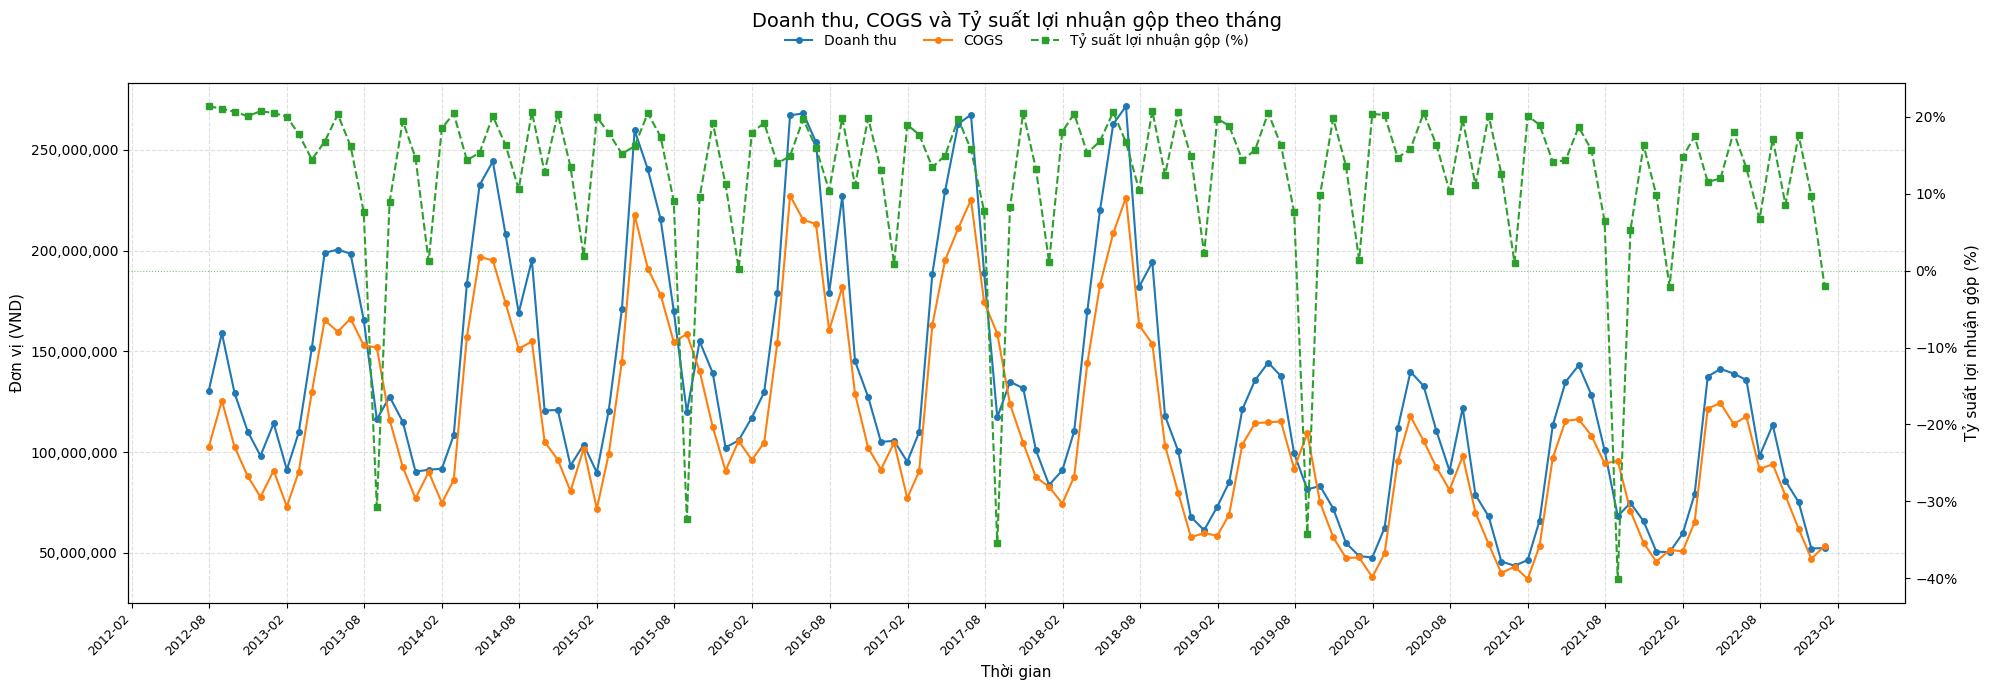

In [26]:
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)
sales['gross_margin_pct'] = np.where(sales['Revenue'] != 0,
                                    (sales['Revenue'] - sales['COGS']) / sales['Revenue'],
                                    np.nan)

# aggregate to month (use 'ME' for month end frequency)
sales_monthly = sales.set_index('Date').resample('ME').sum()[['Revenue','COGS']].reset_index()
sales_monthly['gross_margin_pct'] = np.where(
    sales_monthly['Revenue'] != 0,
    (sales_monthly['Revenue'] - sales_monthly['COGS']) / sales_monthly['Revenue'],
    np.nan
)

fig, ax1 = plt.subplots(figsize=(20, 7))  # rộng hơn nhiều

color_revenue = '#1f77b4'
color_cogs    = '#ff7f0e'
color_margin  = '#2ca02c'

# Trục trái
ax1.plot(sales_monthly['Date'], sales_monthly['Revenue'],
         marker='o', markersize=4, color=color_revenue,
         label='Doanh thu', linewidth=1.5)
ax1.plot(sales_monthly['Date'], sales_monthly['COGS'],
         marker='o', markersize=4, color=color_cogs,
         label='COGS', linewidth=1.5)

ax1.set_xlabel('Thời gian', fontsize=11)
ax1.set_ylabel('Đơn vị (VND)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Trục phải
ax2 = ax1.twinx()
ax2.plot(sales_monthly['Date'], sales_monthly['gross_margin_pct'],
         marker='s', markersize=4, color=color_margin,
         label='Tỷ suất lợi nhuận gộp (%)',
         linewidth=1.5, linestyle='--')
ax2.set_ylabel('Tỷ suất lợi nhuận gộp (%)', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.axhline(0, color=color_margin, linewidth=0.8, linestyle=':', alpha=0.6)

# --- X-axis: mỗi 6 tháng, xoay 45 độ ---
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)

# --- Tiêu đề & legend ---
ax1.set_title('Doanh thu, COGS và Tỷ suất lợi nhuận gộp theo tháng',
              fontsize=14, pad=40)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, 1.12),
           ncol=3, frameon=False, fontsize=10)

ax1.grid(True, linestyle='--', alpha=0.4)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

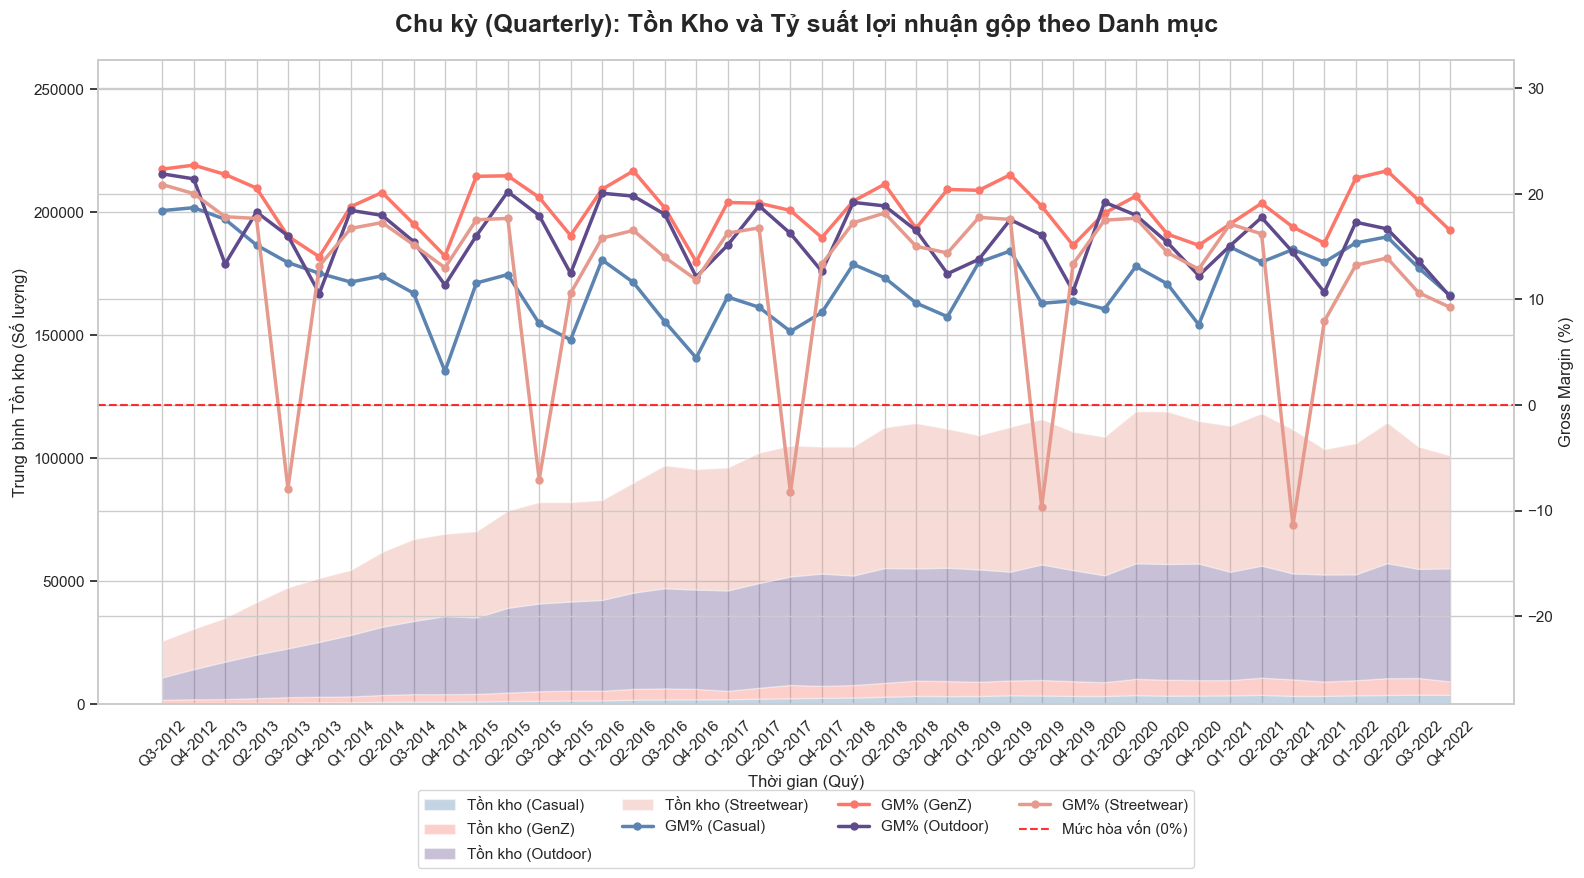

In [ ]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# ==========================================
# 1. TÍNH TỒN KHO THEO QUÝ (AREA CHART) - CẬP NHẬT LOGIC CHUẨN
# ==========================================
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# BƯỚC 1: Tính TỔNG tồn kho của toàn bộ Category trong từng THÁNG
inv_monthly_total = inventory.groupby(['Quarter', 'Month', 'category'])['stock_on_hand'].sum().reset_index()

# BƯỚC 2: Tính TRUNG BÌNH của các tháng đó để ra tồn kho trung bình của QUÝ
inv_quarterly = inv_monthly_total.groupby(['Quarter', 'category'])['stock_on_hand'].mean().reset_index()

# Chuyển đổi để mỗi Category thành 1 cột
inv_pivot = inv_quarterly.pivot(index='Quarter', columns='category', values='stock_on_hand').fillna(0)

# ==========================================
# 2. TÍNH LỢI NHUẬN GỘP THEO QUÝ (LINE CHART)
# ==========================================
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')

# Ghép 3 bảng
sales_df = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sales_df['revenue'] = sales_df['quantity'] * sales_df['unit_price']
sales_df['cogs_total'] = sales_df['quantity'] * sales_df['cogs']

# Nhóm Doanh thu và Giá vốn theo Quý
gm_quarterly = sales_df.groupby(['Quarter', 'category'])[['revenue', 'cogs_total']].sum().reset_index()
gm_quarterly['gm_pct'] = (gm_quarterly['revenue'] - gm_quarterly['cogs_total']) / gm_quarterly['revenue'] * 100
gm_pivot = gm_quarterly.pivot(index='Quarter', columns='category', values='gm_pct').fillna(0)

# ==========================================
# 3. KẾT HỢP VÀ VẼ ĐỒ THỊ
# ==========================================
common_quarters = inv_pivot.index.intersection(gm_pivot.index)
inv_pivot = inv_pivot.loc[common_quarters]
gm_pivot = gm_pivot.loc[common_quarters]
categories = inv_pivot.columns

fig, ax1 = plt.subplots(figsize=(16, 9)) # Tăng chiều cao thêm một chút

colors = ['#5b84b1', '#fc766aff', '#5f4b8bff', '#e69a8dff']
x = np.arange(len(common_quarters))

# --- VẼ AREA CHART: Tồn kho xếp chồng (Trục Y trái) ---
# Dùng stackplot để vẽ biểu đồ miền xếp chồng thay vì bar chart
ax1.stackplot(
    x, 
    [inv_pivot[cat] for cat in categories], 
    labels=[f'Tồn kho ({cat})' for cat in categories], 
    colors=colors, 
    alpha=0.35 # Làm mờ màu đi một chút để trông sang hơn
)

# --- VẼ LINE CHART: Chu kỳ Gross Margin (Trục Y phải) ---
ax2 = ax1.twinx()
for i, cat in enumerate(categories):
    if cat in gm_pivot.columns:
        ax2.plot(x, gm_pivot[cat], label=f'GM% ({cat})', color=colors[i % len(colors)], marker='o', markersize=5, linewidth=2.5)

# --- THỦ THUẬT TÁCH RỜI 2 BIỂU ĐỒ ---
# 1. Ép biểu đồ miền (ax1) dẹt xuống dưới cùng bằng cách nhân đôi trần trục Y
max_inv = inv_pivot.sum(axis=1).max()
ax1.set_ylim(0, max_inv * 2.2) 

# 2. Đẩy biểu đồ đường (ax2) lên trên cùng bằng cách khoét sâu đáy trục Y
min_gm = gm_pivot.min().min() # Đáy sâu nhất (ví dụ: -60%)
max_gm = gm_pivot.max().max() # Đỉnh cao nhất (ví dụ: 30%)
# Đặt giới hạn dưới cực sâu (gấp 2.5 lần đáy) để toàn bộ đường đồ thị nổi lên nửa trên
ax2.set_ylim(min_gm * 2.5, max_gm + 10) 

# --- ĐỊNH DẠNG NHÃN VÀ TRỤC ---
ax1.set_xlabel('Thời gian (Quý)', fontsize=12)
ax1.set_ylabel('Trung bình Tồn kho (Số lượng)', fontsize=12)
ax2.set_ylabel('Gross Margin (%)', fontsize=12)

# Chuyển đổi định dạng nhãn trục X sang dạng Q1-2023, Q2-2023...
ax1.set_xticks(x)
ax1.set_xticklabels([f"Q{q.quarter}-{q.year}" for q in common_quarters], rotation=45)

# Vẽ đường cơ sở 0% màu đỏ cho ax2
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Mức hòa vốn (0%)')

# Gom chú thích
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=11)

plt.title('Chu kỳ (Quarterly): Tồn Kho và Tỷ suất lợi nhuận gộp theo Danh mục', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

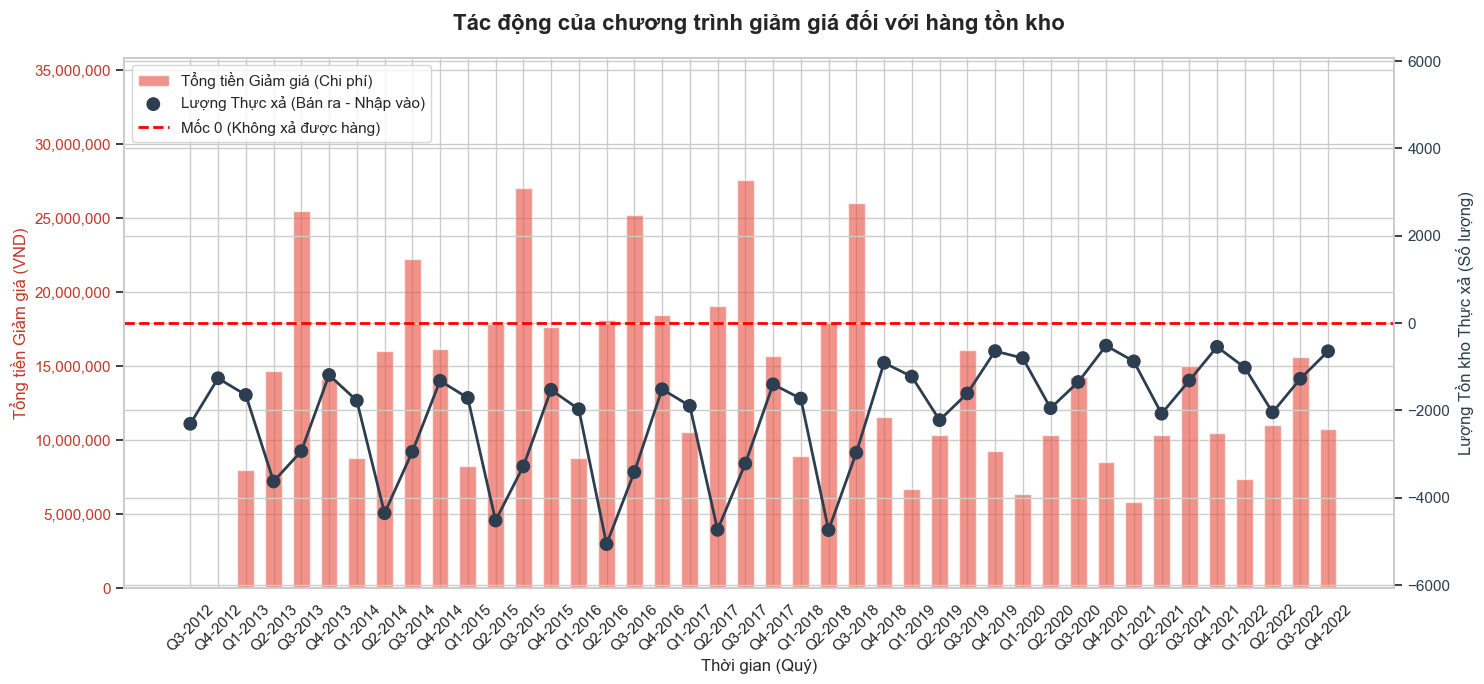

In [ ]:

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ==========================================
# 1. TÍNH TỔNG TIỀN GIẢM GIÁ (TỪ BẢNG ORDERS & ITEMS)
# ==========================================
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')

# Ghép bảng và lọc Streetwear
df_sales = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sw_sales = df_sales[df_sales['category'] == 'Streetwear']

disc_quarterly = sw_sales.groupby('Quarter')['discount_amount'].sum().reset_index()

# ==========================================
# 2. TÍNH LƯỢNG TỒN KHO THỰC XẢ (TỪ BẢNG INVENTORY)
# ==========================================
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# Lọc Streetwear và tính tổng nhập/bán theo Quý
sw_inv = inventory[inventory['category'] == 'Streetwear']
inv_quarterly = sw_inv.groupby('Quarter')[['units_sold', 'units_received']].sum().reset_index()

# Tính Lượng Thực Xả (Net Cleared)
inv_quarterly['net_cleared'] = inv_quarterly['units_sold'] - inv_quarterly['units_received']

# ==========================================
# 3. KẾT HỢP VÀ VẼ ĐỒ THỊ
# ==========================================
merged_df = pd.merge(disc_quarterly, inv_quarterly, on='Quarter', how='inner')

fig, ax1 = plt.subplots(figsize=(15, 7))

x = np.arange(len(merged_df['Quarter']))
quarters_str = [f"Q{q.quarter}-{q.year}" for q in merged_df['Quarter']]

# --- BAR CHART: TỔNG TIỀN GIẢM GIÁ (Trục Y trái) ---
ax1.bar(x, merged_df['discount_amount'], color='#e74c3c', alpha=0.6, width=0.6, label='Tổng tiền Giảm giá (Chi phí)')
ax1.set_xlabel('Thời gian (Quý)', fontsize=12)
ax1.set_ylabel('Tổng tiền Giảm giá (VND)', fontsize=12, color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_xticks(x)
ax1.set_xticklabels(quarters_str, rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))

# --- LINE CHART: LƯỢNG THỰC XẢ (Trục Y phải) ---
ax2 = ax1.twinx()

# Phân loại màu sắc cho đường Line: Xanh nếu xả được hàng (>0), Đen nếu kho vẫn phình to (<0)
colors = ['#27ae60' if val > 0 else '#2c3e50' for val in merged_df['net_cleared']]

ax2.plot(x, merged_df['net_cleared'], color='#2c3e50', linewidth=2, zorder=1) # Vẽ đường nối
ax2.scatter(x, merged_df['net_cleared'], color=colors, s=80, zorder=2, label='Lượng Thực xả (Bán ra - Nhập vào)')

ax2.set_ylabel('Lượng Tồn kho Thực xả (Số lượng)', fontsize=12, color='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#2c3e50')

# VẼ ĐƯỜNG RANH GIỚI SINH TỬ (Mốc 0)
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='Mốc 0 (Không xả được hàng)')

# Tinh chỉnh giới hạn trục Y
ax1.set_ylim(0, merged_df['discount_amount'].max() * 1.3)
# Đảm bảo trục Y bên phải hiển thị rõ cả phần âm và phần dương
max_abs_val = max(abs(merged_df['net_cleared'].max()), abs(merged_df['net_cleared'].min()))
ax2.set_ylim(-max_abs_val * 1.2, max_abs_val * 1.2)

# Gom chú thích
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

plt.title('Tác động của chương trình giảm giá đối với hàng tồn kho', fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

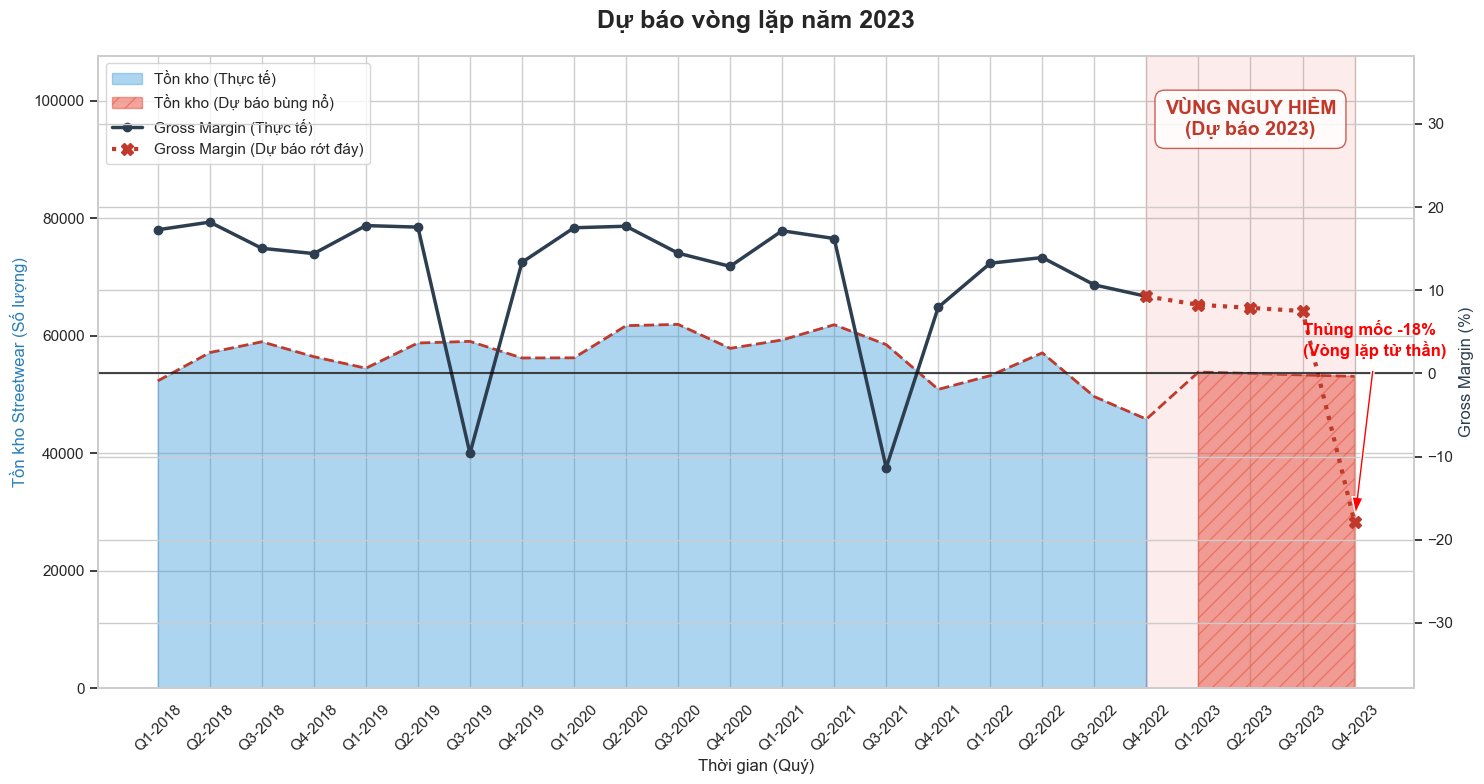

In [ ]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# ==========================================
# 1. TÍNH TOÁN DỮ LIỆU LỊCH SỬ (Đến hết 2022)
# ==========================================

# Xử lý thời gian
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# LỌC RIÊNG STREETWEAR
sw_inv = inventory[inventory['category'] == 'Streetwear']
df_sales = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sw_sales = df_sales[df_sales['category'] == 'Streetwear'].copy()

# Tính Tồn kho lịch sử
inv_monthly = sw_inv.groupby(['Quarter', 'Month'])['stock_on_hand'].sum().reset_index()
hist_inv = inv_monthly.groupby('Quarter')['stock_on_hand'].mean().reset_index()

# Tính Gross Margin lịch sử
sw_sales['revenue'] = sw_sales['quantity'] * sw_sales['unit_price']
sw_sales['cogs_total'] = sw_sales['quantity'] * sw_sales['cogs']
hist_gm = sw_sales.groupby('Quarter')[['revenue', 'cogs_total']].sum().reset_index()
hist_gm['gm_pct'] = (hist_gm['revenue'] - hist_gm['cogs_total']) / hist_gm['revenue'] * 100

# Gộp dữ liệu lịch sử
df_hist = pd.merge(hist_inv, hist_gm[['Quarter', 'gm_pct']], on='Quarter', how='inner')
# Lọc từ năm 2018 trở đi để thấy rõ đà tăng tốc của "hòn tuyết lăn"
df_hist = df_hist[df_hist['Quarter'] >= '2018Q1'].reset_index(drop=True)

# ==========================================
# 2. NGOẠI SUY & DỰ BÁO CHO NĂM 2023 (PREDICTIVE)
# ==========================================
# Tạo các quý của năm 2023
quarters_2023 = pd.period_range(start='2023Q1', end='2023Q4', freq='Q')
x_hist = np.arange(len(df_hist))
x_pred = np.arange(len(df_hist), len(df_hist) + 4)

# Mô hình hóa đà tăng Tồn kho (Dùng hồi quy bậc 1)
z_inv = np.polyfit(x_hist, df_hist['stock_on_hand'], 1)
p_inv = np.poly1d(z_inv)
pred_inv = p_inv(x_pred)

# Mô hình hóa đà giảm Margin (Dự báo xu hướng giảm dần của các đáy)
z_gm = np.polyfit(x_hist, df_hist['gm_pct'], 1)
p_gm = np.poly1d(z_gm)
# Thêm "cú shock mùa vụ" cho quý 4/2023 để mô phỏng "Vòng lặp tử thần"
pred_gm = p_gm(x_pred)
pred_gm[-1] -= 25  # Ép Gross Margin Q4-2023 rớt thảm hại do áp lực xả kho khổng lồ

# ==========================================
# 3. VẼ BIỂU ĐỒ TRỰC QUAN HÓA CẢNH BÁO
# ==========================================
fig, ax1 = plt.subplots()

# Nối trục X
all_x = np.concatenate([x_hist, x_pred])
all_quarters = [f"Q{q.quarter}-{q.year}" for q in df_hist['Quarter']] + [f"Q{q.quarter}-{q.year}" for q in quarters_2023]

# --- VẼ TỒN KHO (HIỆU ỨNG HÒN TUYẾT LĂN) ---
# Tồn kho lịch sử
ax1.fill_between(x_hist, 0, df_hist['stock_on_hand'], color='#3498db', alpha=0.4, label='Tồn kho (Thực tế)')
# Tồn kho dự báo 2023
ax1.fill_between(x_pred, 0, pred_inv, color='#e74c3c', alpha=0.5, hatch='//', label='Tồn kho (Dự báo bùng nổ)')
ax1.plot(all_x, np.concatenate([df_hist['stock_on_hand'], pred_inv]), color='#c0392b', linestyle='--', linewidth=2)

ax1.set_xlabel('Thời gian (Quý)', fontsize=12)
ax1.set_ylabel('Tồn kho Streetwear (Số lượng)', fontsize=12, color='#2980b9')
ax1.set_ylim(0, max(pred_inv) * 2.0) # Đẩy dẹt xuống để nhường chỗ cho Line chart

# --- VẼ GROSS MARGIN (VÒNG LẶP TỬ THẦN) ---
ax2 = ax1.twinx()
# Lịch sử
ax2.plot(x_hist, df_hist['gm_pct'], color='#2c3e50', marker='o', linewidth=2.5, label='Gross Margin (Thực tế)')
# Dự báo
ax2.plot(np.concatenate([x_hist[-1:], x_pred]), np.concatenate([df_hist['gm_pct'].tail(1), pred_gm]), 
         color='#c0392b', marker='X', markersize=8, linestyle=':', linewidth=3, label='Gross Margin (Dự báo rớt đáy)')

# Đường ranh giới hòa vốn
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax2.set_ylabel('Gross Margin (%)', fontsize=12, color='#2c3e50')
ax2.set_ylim(min(pred_gm) - 20, max(df_hist['gm_pct']) + 20)

# --- VÙNG CẢNH BÁO (DANGER ZONE) ---
ax1.axvspan(x_hist[-1], x_pred[-1], color='#e74c3c', alpha=0.1)
plt.text(x_pred[1], ax2.get_ylim()[1]*0.8, 'VÙNG NGUY HIỂM\n(Dự báo 2023)', 
         color='#c0392b', fontsize=14, fontweight='bold', ha='center', va='center',
         bbox=dict(facecolor='white', edgecolor='#c0392b', boxstyle='round,pad=0.5', alpha=0.8))

# Mũi tên chỉ vào đáy Q4-2023
ax2.annotate('Thủng mốc -18%\n(Vòng lặp tử thần)', xy=(x_pred[-1], pred_gm[-1]), 
             xytext=(x_pred[-2], pred_gm[-1] + 20),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             fontsize=12, color='red', fontweight='bold')

# Nhãn trục X
ax1.set_xticks(all_x)
ax1.set_xticklabels(all_quarters, rotation=45)

# Gom legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

plt.title('Dự báo vòng lặp năm 2023', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

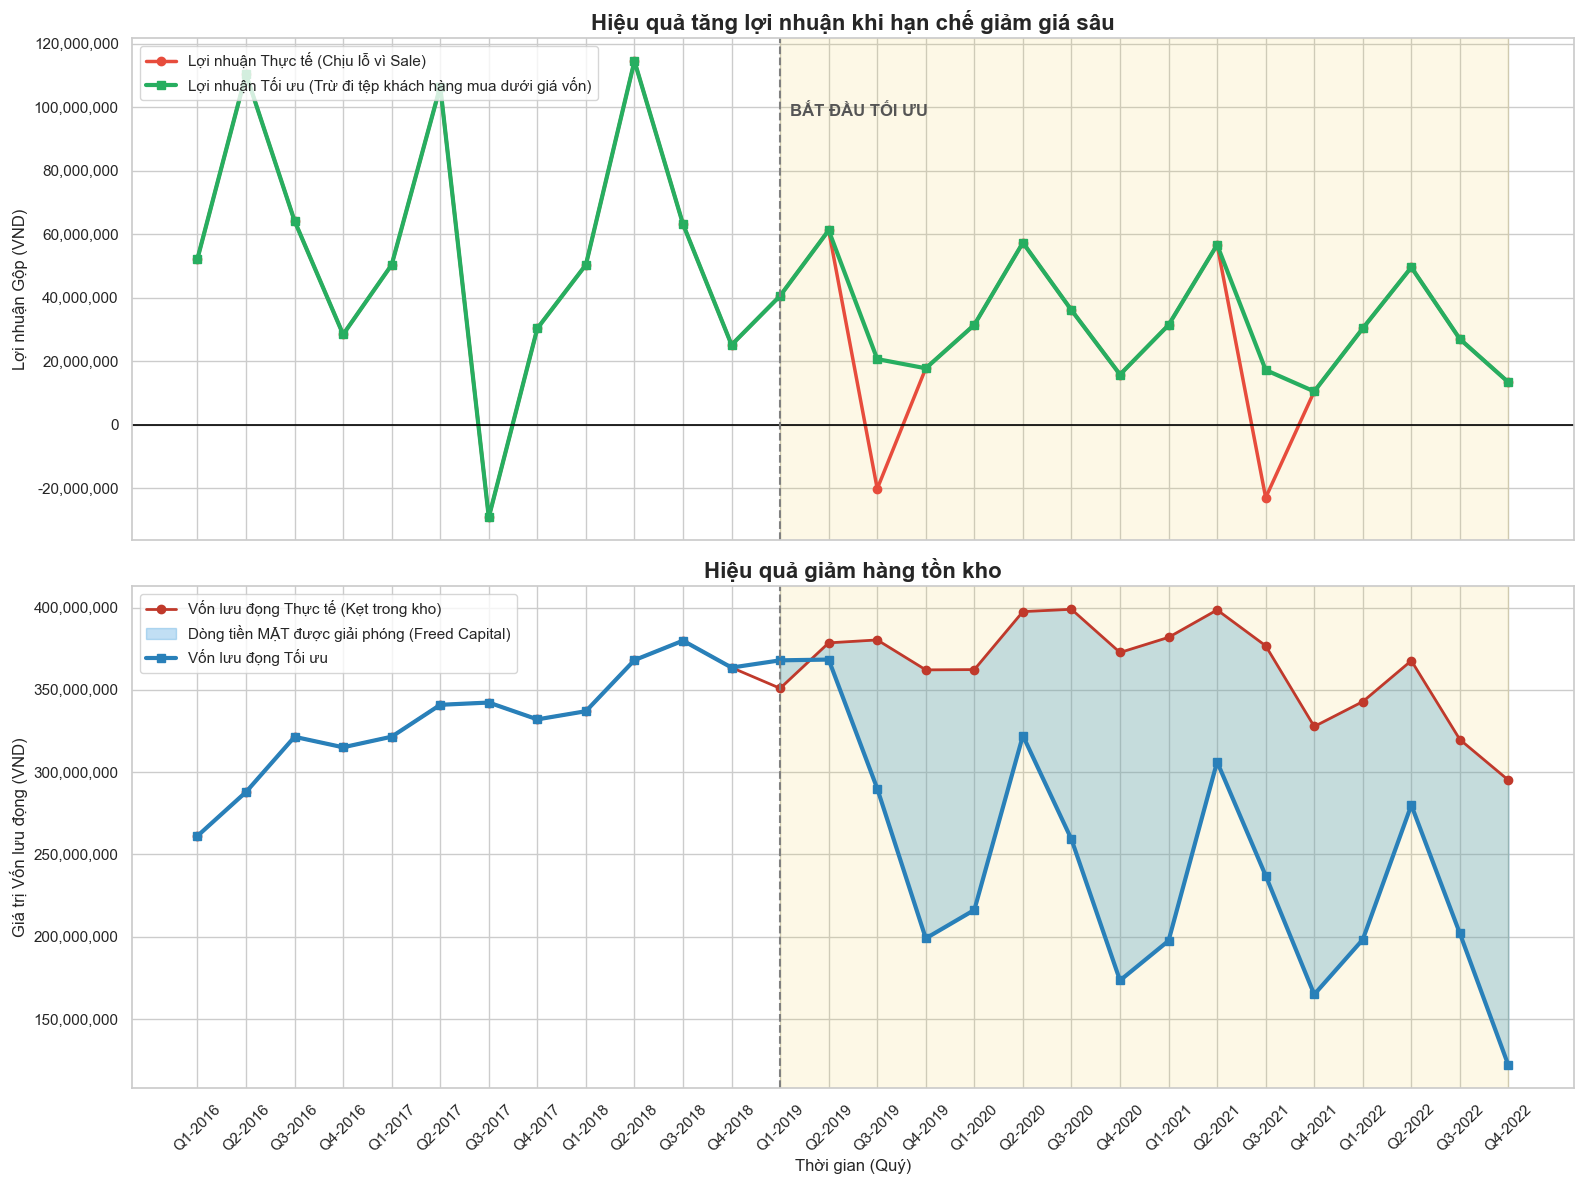

In [ ]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU ĐẾN MỨC PHÂN KHÚC (SEGMENT)
# ==========================================

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')

# --- Dữ liệu Streetwear theo Segment ---
sw_sales = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sw_sales = sw_sales[sw_sales['category'] == 'Streetwear'].copy()

# Tính giá vốn trung bình (Average COGS) để định giá tồn kho
avg_cogs = sw_sales['cogs'].mean()

sw_sales['actual_revenue'] = sw_sales['quantity'] * sw_sales['unit_price']
sw_sales['actual_cogs_total'] = sw_sales['quantity'] * sw_sales['cogs']

# ---> TÌM VÀ ĐO LƯỜNG GIAO DỊCH BÁN LỖ TỪ DỮ LIỆU GỐC (GIỮ NGUYÊN) <---
sw_sales['is_loss'] = sw_sales['unit_price'] < sw_sales['cogs']
sw_sales['loss_qty'] = np.where(sw_sales['is_loss'], sw_sales['quantity'], 0)
sw_sales['loss_revenue'] = np.where(sw_sales['is_loss'], sw_sales['actual_revenue'], 0)
sw_sales['loss_profit'] = np.where(sw_sales['is_loss'], sw_sales['actual_revenue'] - sw_sales['actual_cogs_total'], 0)

# Gom nhóm và tính tổng cả phần thực tế lẫn phần bị lỗ
df_financials_seg = sw_sales.groupby(['Quarter', 'segment']).agg(
    actual_revenue=('actual_revenue', 'sum'),
    actual_cogs_total=('actual_cogs_total', 'sum'),
    quantity=('quantity', 'sum'),
    loss_qty=('loss_qty', 'sum'),           
    loss_revenue=('loss_revenue', 'sum'),   
    loss_profit=('loss_profit', 'sum')      
).reset_index()

df_financials_seg['actual_profit'] = df_financials_seg['actual_revenue'] - df_financials_seg['actual_cogs_total']
df_financials_seg['actual_gm_pct'] = df_financials_seg['actual_profit'] / df_financials_seg['actual_revenue'] * 100

# --- Tính Tồn kho theo Segment (GIỮ NGUYÊN 100%) ---
sw_inv = inventory[inventory['category'] == 'Streetwear']
inv_monthly_seg = sw_inv.groupby(['Quarter', 'Month', 'segment'])[['stock_on_hand', 'units_sold', 'units_received']].sum().reset_index()
df_inv_seg = inv_monthly_seg.groupby(['Quarter', 'segment']).agg(
    actual_stock=('stock_on_hand', 'mean'),
    actual_received=('units_received', 'sum')
).reset_index()

# Gộp bảng
df_sim_seg = pd.merge(df_inv_seg, df_financials_seg, on=['Quarter', 'segment'], how='inner')
df_sim_seg = df_sim_seg[df_sim_seg['Quarter'] >= '2016Q1'].reset_index(drop=True)

# ==========================================
# 2. CHẠY MÔ PHỎNG TỐI ƯU HÓA NHẮM MỤC TIÊU (Áp dụng từ 2019Q1)
# ==========================================
start_q = pd.Period('2019Q1', freq='Q')

# Ép kiểu float
df_sim_seg['opt_revenue'] = df_sim_seg['actual_revenue'].astype(float)
df_sim_seg['opt_profit'] = df_sim_seg['actual_profit'].astype(float)
df_sim_seg['opt_stock'] = df_sim_seg['actual_stock'].astype(float)
df_sim_seg['opt_sold_qty'] = df_sim_seg['quantity'].astype(float)

segments = df_sim_seg['segment'].unique()

for seg in segments:
    seg_mask = df_sim_seg['segment'] == seg
    idx_list = df_sim_seg[seg_mask].index.tolist()
    
    start_idx_list = df_sim_seg[(seg_mask) & (df_sim_seg['Quarter'] == start_q)].index
    if len(start_idx_list) == 0: continue
    start_idx = start_idx_list[0]
    
    current_stock = df_sim_seg.loc[start_idx - 1, 'actual_stock']
    
    for i in idx_list:
        if df_sim_seg.loc[i, 'Quarter'] >= start_q:
            
            # --- QUY TẮC 1 THEO DỮ LIỆU THỰC (GIỮ NGUYÊN) ---
            if df_sim_seg.loc[i, 'actual_gm_pct'] < 0:
                df_sim_seg.loc[i, 'opt_sold_qty'] = df_sim_seg.loc[i, 'quantity'] - df_sim_seg.loc[i, 'loss_qty']
                df_sim_seg.loc[i, 'opt_revenue'] = df_sim_seg.loc[i, 'actual_revenue'] - df_sim_seg.loc[i, 'loss_revenue']
                df_sim_seg.loc[i, 'opt_profit'] = df_sim_seg.loc[i, 'actual_profit'] - df_sim_seg.loc[i, 'loss_profit']
            else:
                pass
            
            # ---> THAY ĐỔI: QUY TẮC 2 XẢ HÀNG THEO NGƯỠNG TỒN KHO AN TOÀN <---
            # Giới hạn an toàn: Tồn kho cuối kỳ mục tiêu bằng đúng 100% lượng bán ra của quý đó
            safe_stock_target = df_sim_seg.loc[i, 'opt_sold_qty'] * 1.0
            
            # Tính toán lượng cần nhập để duy trì mức an toàn (Nhập = Tồn mục tiêu - Tồn hiện tại + Lượng sẽ bán)
            required_received = safe_stock_target - current_stock + df_sim_seg.loc[i, 'opt_sold_qty']
            
            # Nếu required_received < 0 (kho đang phình to vượt mức an toàn), cấm nhập (opt_received = 0) để ép xả kho
            # Ngược lại, nếu kho thiếu hàng, nhập đủ số lượng required_received để đưa về mốc an toàn
            opt_received = max(required_received, 0)
                
            current_stock = current_stock + opt_received - df_sim_seg.loc[i, 'opt_sold_qty']
            df_sim_seg.loc[i, 'opt_stock'] = max(current_stock, 0)

# ==========================================
# 3. GỘP (ROLL-UP) LẠI VÀ TÍNH VỐN LƯU ĐỌNG
# ==========================================
df_final = df_sim_seg.groupby('Quarter').agg(
    actual_stock=('actual_stock', 'sum'),
    opt_stock=('opt_stock', 'sum'),
    actual_profit=('actual_profit', 'sum'),
    opt_profit=('opt_profit', 'sum'),
    actual_revenue=('actual_revenue', 'sum'),
    opt_revenue=('opt_revenue', 'sum')
).reset_index()

df_final['actual_trapped_capital'] = df_final['actual_stock'] * avg_cogs
df_final['opt_trapped_capital'] = df_final['opt_stock'] * avg_cogs
df_final['freed_capital'] = df_final['actual_trapped_capital'] - df_final['opt_trapped_capital']

# ==========================================
# 4. VẼ DASHBOARD
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
x = np.arange(len(df_final))

start_idx_plot = df_final.index[df_final['Quarter'] == start_q].tolist()[0]

# --- BIỂU ĐỒ 1 CHUYỂN SANG LINE CHART (GIỮ NGUYÊN) ---
ax1.plot(x, df_final['actual_profit'], color='#e74c3c', marker='o', linestyle='-', linewidth=2.5, label='Lợi nhuận Thực tế (Chịu lỗ vì Sale)')
ax1.plot(x, df_final['opt_profit'], color='#27ae60', marker='s', linestyle='-', linewidth=3, label='Lợi nhuận Tối ưu (Trừ đi tệp khách hàng mua dưới giá vốn)')

ax1.axhline(0, color='black', linestyle='-', linewidth=1.2)
ax1.axvspan(start_idx_plot, x[-1], color='#f1c40f', alpha=0.1)
ax1.axvline(start_idx_plot, color='gray', linestyle='--', linewidth=1.5)
ax1.text(start_idx_plot + 0.2, ax1.get_ylim()[1]*0.8, 'BẮT ĐẦU TỐI ƯU', color='#555555', fontweight='bold')

ax1.set_title('Hiệu quả tăng lợi nhuận khi hạn chế giảm giá sâu', fontsize=16, fontweight='bold')
ax1.set_ylabel('Lợi nhuận Gộp (VND)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))
ax1.legend(loc='upper left', fontsize=11)

# --- BIỂU ĐỒ 2: GIẢI PHÓNG VỐN LƯU ĐỌNG BẰNG HÀNG TỒN KHO (GIỮ NGUYÊN 100%) ---
ax2.plot(x, df_final['actual_trapped_capital'], color='#c0392b', marker='o', linewidth=2, label='Vốn lưu đọng Thực tế (Kẹt trong kho)')
ax2.fill_between(x, df_final['opt_trapped_capital'], df_final['actual_trapped_capital'], where=(x >= start_idx_plot), color='#3498db', alpha=0.3, label='Dòng tiền MẶT được giải phóng (Freed Capital)')
ax2.plot(x, df_final['opt_trapped_capital'], color='#2980b9', marker='s', linewidth=3, label='Vốn lưu đọng Tối ưu')

ax2.axvspan(start_idx_plot, x[-1], color='#f1c40f', alpha=0.1)
ax2.axvline(start_idx_plot, color='gray', linestyle='--', linewidth=1.5)

ax2.set_title('Hiệu quả giảm hàng tồn kho', fontsize=16, fontweight='bold')
ax2.set_ylabel('Giá trị Vốn lưu đọng (VND)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))
ax2.legend(loc='upper left', fontsize=11)

plt.xticks(x, [f"Q{q.quarter}-{q.year}" for q in df_final['Quarter']], rotation=45)
plt.xlabel('Thời gian (Quý)', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_33308\1555635022.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


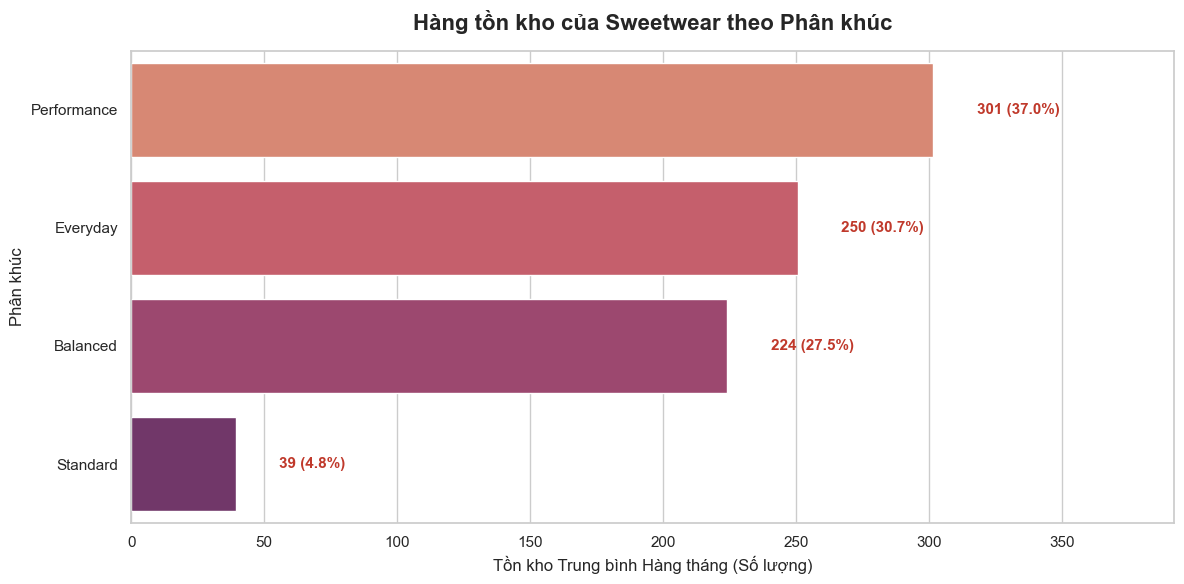

In [ ]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# 1. ĐỌC VÀ LỌC DỮ LIỆU
# ==========================================
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Lọc riêng Streetwear VÀ thu hẹp vào năm 2019 theo gợi ý của bạn
sw_inv_2019 = inventory[(inventory['category'] == 'Streetwear') & (inventory['snapshot_date'].dt.year == 2019)].copy()

# ==========================================
# 2. TÍNH TOÁN THEO LOGIC CHUẨN (DÙNG MEAN)
# ==========================================
# Dùng .mean() để tính Trung bình Tồn kho hàng tháng trong năm 2019 của từng Segment
segment_stock = sw_inv_2019.groupby('segment')['stock_on_hand'].mean().reset_index()

# Sắp xếp từ cao xuống thấp
segment_stock = segment_stock.sort_values(by='stock_on_hand', ascending=False)

# Tính tỷ trọng Phần trăm (%) dựa trên tổng trung bình
total_sw_stock = segment_stock['stock_on_hand'].sum()
segment_stock['percentage'] = (segment_stock['stock_on_hand'] / total_sw_stock) * 100

# ==========================================
# 3. VẼ BIỂU ĐỒ BÓC TÁCH (DRILL-DOWN)
# ==========================================
fig, ax = plt.subplots()

# Vẽ Bar Chart ngang
bars = sns.barplot(
    data=segment_stock, 
    x='stock_on_hand', 
    y='segment', 
    palette='flare', # Dùng tone màu nóng để cảnh báo
    ax=ax
)

# Thêm nhãn số lượng và phần trăm vào đuôi mỗi cột
for i, p in enumerate(bars.patches):
    width = p.get_width()
    percentage = segment_stock.iloc[i]['percentage']
    ax.text(
        width + (total_sw_stock * 0.02), # Đẩy chữ ra xa một chút cho thoáng
        p.get_y() + p.get_height() / 2,
        f"{int(width):,} ({percentage:.1f}%)", 
        ha="left", va="center", fontweight='bold', fontsize=11, color='#c0392b'
    )

ax.set_title('Hàng tồn kho của Sweetwear theo Phân khúc', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Tồn kho Trung bình Hàng tháng (Số lượng)', fontsize=12)
ax.set_ylabel('Phân khúc', fontsize=12)

# Nới rộng giới hạn trục X để chữ không bị cắt khỏi khung hình
ax.set_xlim(0, segment_stock['stock_on_hand'].max() * 1.3)

plt.tight_layout()
plt.show()